# Logistic Regression

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)


: 

In [ ]:
# Preprocess data
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
df = df.replace('?', pd.NA).dropna()

In [ ]:
# Define features and target
X = df.drop('target', axis=1)
y = df['target']

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Initialize and train logistic regression model
logreg = LogisticRegression(max_iter=10000,solver='lbfgs')
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [ ]:
print(logreg.n_iter_)

[1043]


In [ ]:
# Make predictions
y_pred = logreg.predict(X_test)

In [ ]:
y_pred_pro = logreg.predict_proba(X_test)#[:,1]
y_pred_pro

array([[0.97485827, 0.02514173],
       [0.76253061, 0.23746939],
       [0.9785972 , 0.0214028 ],
       [0.01382107, 0.98617893],
       [0.95529613, 0.04470387],
       [0.56395279, 0.43604721],
       [0.8846096 , 0.1153904 ],
       [0.41164705, 0.58835295],
       [0.26362975, 0.73637025],
       [0.88239891, 0.11760109],
       [0.47058464, 0.52941536],
       [0.90214256, 0.09785744],
       [0.98605795, 0.01394205],
       [0.77577524, 0.22422476],
       [0.61903505, 0.38096495],
       [0.98603835, 0.01396165],
       [0.77255911, 0.22744089],
       [0.56474999, 0.43525001],
       [0.43195658, 0.56804342],
       [0.92323853, 0.07676147],
       [0.16975107, 0.83024893],
       [0.31889572, 0.68110428],
       [0.40059313, 0.59940687],
       [0.88346091, 0.11653909],
       [0.19726575, 0.80273425],
       [0.92909337, 0.07090663],
       [0.05071722, 0.94928278],
       [0.42943428, 0.57056572],
       [0.78677527, 0.21322473],
       [0.94873969, 0.05126031],
       [0.

In [ ]:
y_pred

array([0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 1])

In [ ]:
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[47  2]
 [ 8 33]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.96      0.90        49
           1       0.94      0.80      0.87        41

    accuracy                           0.89        90
   macro avg       0.90      0.88      0.89        90
weighted avg       0.89      0.89      0.89        90



# Classification Metrics

Confusion Matrix

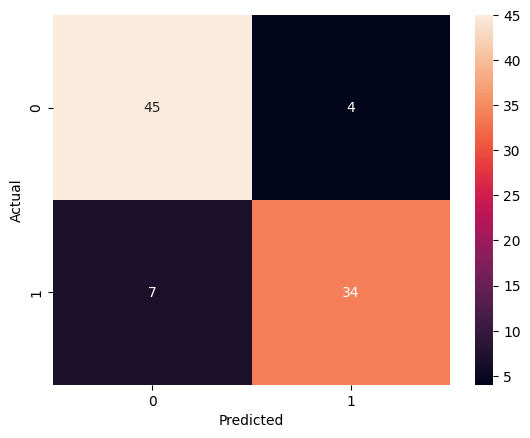

In [ ]:
# Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ROC and AUC

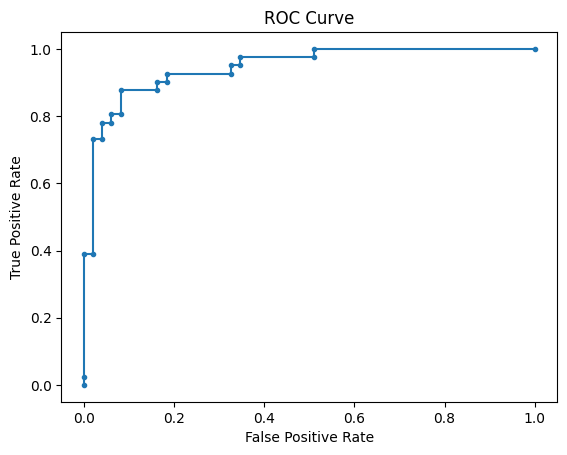

AUC Score: 0.9462419113987058


In [ ]:
y_prob = logreg.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, marker='.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc_score}")